# Market Population Dynamics — Base Model Prototype

**Goal**: Simulate a market with three behaviorally-distinct trader populations and study how their relative proportions affect price convergence to fair value.

## Model Overview

The market price $P(t)$ evolves according to aggregate excess demand from three agent types, weighted by their population fractions $\mathbf{p} = (p_1, p_2, p_3)$ with $p_1 + p_2 + p_3 = 1$.

$$dP = \lambda \left[ p_1 D_1(t) + p_2 D_2(t) + p_3 D_3(t) \right] dt + \sigma_f dW_f$$

where $\lambda$ is the price impact parameter and $\sigma_f dW_f$ is fundamental news noise.

### Agent Types

**Type I — Data-Driven / Value Traders**
$$D_1(t) = \kappa (V^* - P(t))$$
Mean-revert toward estimated fair value $V^*$. When $p_1 = 1$, the market should converge to $V^*$ (EMH limit).

**Type II — Intuition / Emotion Traders**
$$D_2(t) = \alpha \cdot m(t) + \beta \cdot S(t)$$
where $m(t)$ is a momentum signal (exponentially weighted recent returns) and $S(t)$ is a sentiment field.

Momentum: $m(t) = \text{EWMA of } r(t)$ with lookback $\tau_m$

Sentiment dynamics with prospect-theoretic asymmetry:
$$dS = -\gamma S \, dt + \delta \cdot v(r) \, dt + \sigma_s dW_s$$
where $v(r)$ is the Kahneman-Tversky value function:
$$v(r) = \begin{cases} r^a & r \geq 0 \\ -\lambda_{PT} (-r)^a & r < 0 \end{cases}$$
with $\lambda_{PT} \approx 2.25$ (loss aversion) and $a \approx 0.88$.

**Type III — Noise Traders**
$$D_3(t) = \sigma_n \cdot \varepsilon(t), \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.tri as mtri
from dataclasses import dataclass
from typing import Tuple

np.random.seed(42)

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 1. Model Parameters

In [ ]:
@dataclass
class ModelParams:
    """Parameters for the market population dynamics model."""
    
    # Simulation
    T: float = 10.0          # total time (years)
    dt: float = 1/252        # time step (1 trading day)
    V_star: float = 100.0    # fair value
    P0: float = 100.0        # initial price
    
    # Market microstructure
    lam: float = 0.5         # price impact (Kyle's lambda)
    sigma_f: float = 0.01    # fundamental news volatility (daily)
    
    # Type I: Data-driven / Value
    kappa: float = 2.0       # mean-reversion speed
    
    # Type II: Intuition / Emotion
    alpha: float = 5.0       # momentum sensitivity
    beta: float = 3.0        # sentiment sensitivity
    tau_m: float = 20/252    # momentum lookback (~20 days)
    gamma: float = 5.0       # sentiment mean-reversion
    delta: float = 10.0      # sentiment response to returns
    sigma_s: float = 0.5     # sentiment noise
    lam_pt: float = 2.25     # prospect theory loss aversion
    a_pt: float = 0.88       # prospect theory curvature
    
    # Type III: Noise
    sigma_n: float = 1.0     # noise trader demand volatility
    
    @property
    def n_steps(self) -> int:
        return int(self.T / self.dt)
    
    @property
    def ewma_decay(self) -> float:
        """EWMA decay factor for momentum calculation."""
        return np.exp(-self.dt / self.tau_m)


params = ModelParams()
print(f"Simulation: {params.T} years, {params.n_steps} steps (dt = {params.dt:.6f})")
print(f"EWMA decay factor: {params.ewma_decay:.4f}")

Simulation: 10.0 years, 2520 steps (dt = 0.003968)
EWMA decay factor: 0.9512


## 2. Prospect Theory Value Function

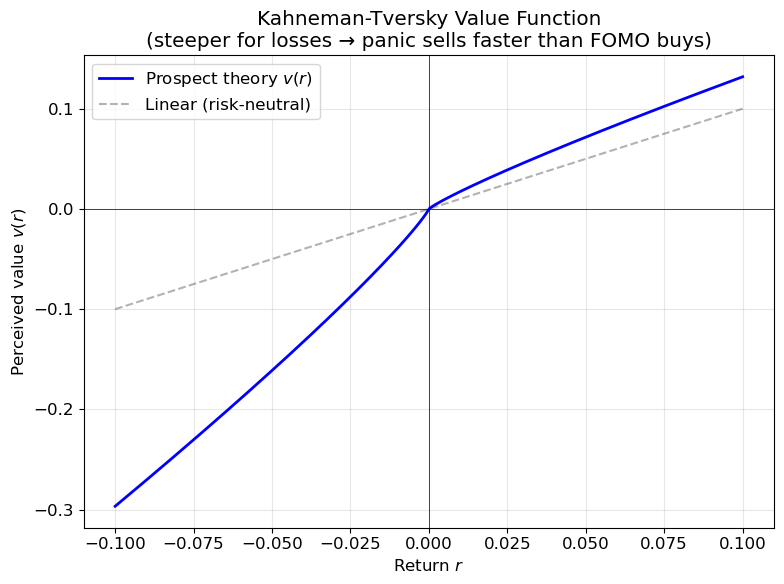

In [21]:
def prospect_value(r: np.ndarray, lam_pt: float = 2.25, a: float = 0.88) -> np.ndarray:
    """Kahneman-Tversky value function.
    
    v(r) = r^a          if r >= 0
    v(r) = -lam * |r|^a if r < 0
    
    Key property: steeper for losses than gains (loss aversion).
    """
    result = np.where(
        r >= 0,
        np.power(np.maximum(r, 0), a),
        -lam_pt * np.power(np.maximum(-r, 0), a)
    )
    return result


# Visualize the value function
r_range = np.linspace(-0.1, 0.1, 500)
v_vals = prospect_value(r_range)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(r_range, v_vals, 'b-', linewidth=2, label='Prospect theory $v(r)$')
ax.plot(r_range, r_range, 'k--', alpha=0.3, label='Linear (risk-neutral)')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('Return $r$')
ax.set_ylabel('Perceived value $v(r)$')
ax.set_title('Kahneman-Tversky Value Function\n(steeper for losses → panic sells faster than FOMO buys)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Simulation Engine

In [5]:
def simulate_market(
    p: Tuple[float, float, float],
    params: ModelParams = ModelParams(),
    seed: int = None,
) -> dict:
    """Simulate market dynamics for a given population mix.
    
    Args:
        p: (p1, p2, p3) population fractions, must sum to 1.
        params: model parameters.
        seed: random seed for reproducibility.
    
    Returns:
        dict with time series: prices, fair_value, sentiment, demands, returns.
    """
    if seed is not None:
        np.random.seed(seed)
    
    p1, p2, p3 = p
    assert abs(p1 + p2 + p3 - 1.0) < 1e-10, f"Population fractions must sum to 1, got {p1+p2+p3}"
    
    n = params.n_steps
    dt = params.dt
    sqrt_dt = np.sqrt(dt)
    
    # Pre-allocate arrays
    P = np.zeros(n + 1)       # price
    V = np.zeros(n + 1)       # fair value (random walk with drift=0)
    S = np.zeros(n + 1)       # sentiment
    m = np.zeros(n + 1)       # momentum signal
    D1 = np.zeros(n + 1)      # value trader demand
    D2 = np.zeros(n + 1)      # emotion trader demand
    D3 = np.zeros(n + 1)      # noise trader demand
    returns = np.zeros(n + 1) # log returns
    
    # Initial conditions
    P[0] = params.P0
    V[0] = params.V_star
    S[0] = 0.0
    m[0] = 0.0
    
    # Random draws (all at once for efficiency)
    dW_f = np.random.randn(n) * sqrt_dt   # fundamental news
    dW_s = np.random.randn(n) * sqrt_dt   # sentiment noise
    dW_n = np.random.randn(n) * sqrt_dt   # noise trader shocks
    
    decay = params.ewma_decay
    
    for t in range(n):
        # Fair value: random walk (geometric Brownian motion)
        V[t + 1] = V[t] * np.exp(params.sigma_f * dW_f[t] / sqrt_dt * sqrt_dt 
                                   - 0.5 * params.sigma_f**2 * dt)
        # Actually, simpler: V follows GBM with zero drift
        V[t + 1] = V[t] * np.exp(-0.5 * params.sigma_f**2 * dt + params.sigma_f * dW_f[t])
        
        # Compute demands
        # Type I: mean-revert to fair value
        D1[t] = params.kappa * (V[t] - P[t]) / P[t]  # normalized by price
        
        # Type II: momentum + sentiment
        D2[t] = params.alpha * m[t] + params.beta * S[t]
        
        # Type III: pure noise
        D3[t] = params.sigma_n * dW_n[t] / sqrt_dt  # white noise demand
        
        # Aggregate demand → price change
        D_total = p1 * D1[t] + p2 * D2[t] + p3 * D3[t]
        
        # Price update (log-normal to prevent negative prices)
        dP = params.lam * D_total * dt
        P[t + 1] = P[t] * np.exp(dP - 0.5 * (params.lam * D_total)**2 * dt**2)
        
        # Log return
        returns[t + 1] = np.log(P[t + 1] / P[t])
        
        # Update momentum (EWMA of returns)
        m[t + 1] = decay * m[t] + (1 - decay) * returns[t + 1]
        
        # Update sentiment with prospect-theoretic asymmetry
        v_r = prospect_value(
            np.array([returns[t + 1]]),
            lam_pt=params.lam_pt,
            a=params.a_pt
        )[0]
        dS = -params.gamma * S[t] * dt + params.delta * v_r * dt + params.sigma_s * dW_s[t]
        S[t + 1] = S[t] + dS
    
    time = np.arange(n + 1) * dt
    
    return {
        'time': time,
        'price': P,
        'fair_value': V,
        'sentiment': S,
        'momentum': m,
        'demand_value': D1,
        'demand_emotion': D2,
        'demand_noise': D3,
        'returns': returns,
        'mispricing': np.log(P / V),  # log(P/V*)
    }

## 4. Boundary Case Verification

Before analyzing the full simplex, verify the model behaves correctly at the three corners:
- $\mathbf{p} = (1, 0, 0)$: 100% value traders → price should converge to $V^*$
- $\mathbf{p} = (0, 1, 0)$: 100% emotion traders → momentum cascades, bubbles/crashes
- $\mathbf{p} = (0, 0, 1)$: 100% noise → random walk around fair value

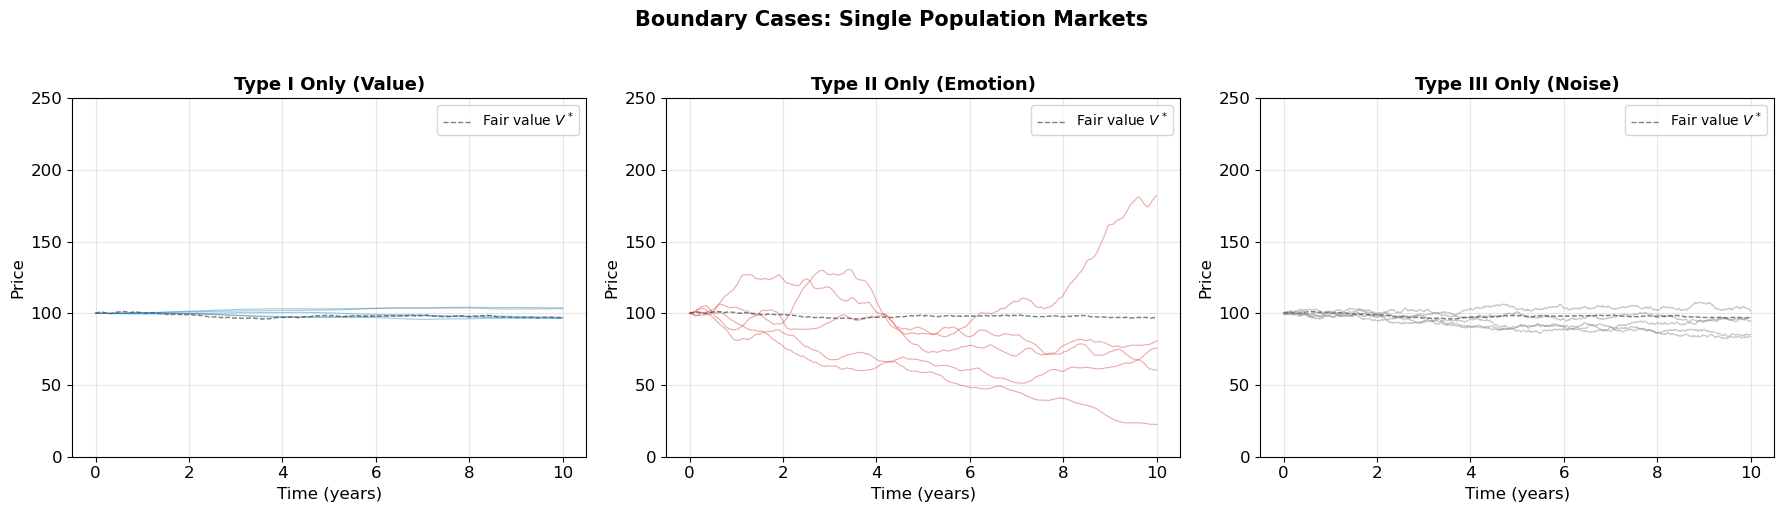

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cases = [
    ((1.0, 0.0, 0.0), 'Type I Only (Value)', 'tab:blue'),
    ((0.0, 1.0, 0.0), 'Type II Only (Emotion)', 'tab:red'),
    ((0.0, 0.0, 1.0), 'Type III Only (Noise)', 'tab:gray'),
]

for ax, (pop, title, color) in zip(axes, cases):
    # Run 5 paths for each case
    for i in range(5):
        result = simulate_market(pop, params, seed=i)
        ax.plot(result['time'], result['price'], color=color, alpha=0.4, linewidth=0.8)
        if i == 0:
            ax.plot(result['time'], result['fair_value'], 'k--', 
                    alpha=0.5, linewidth=1, label='Fair value $V^*$')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Price')
    ax.legend(loc='upper right', fontsize=10)
    ax.set_ylim(0, max(250, ax.get_ylim()[1]))

plt.suptitle('Boundary Cases: Single Population Markets', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Population Mix Comparison

Compare several interesting population mixes to build intuition.

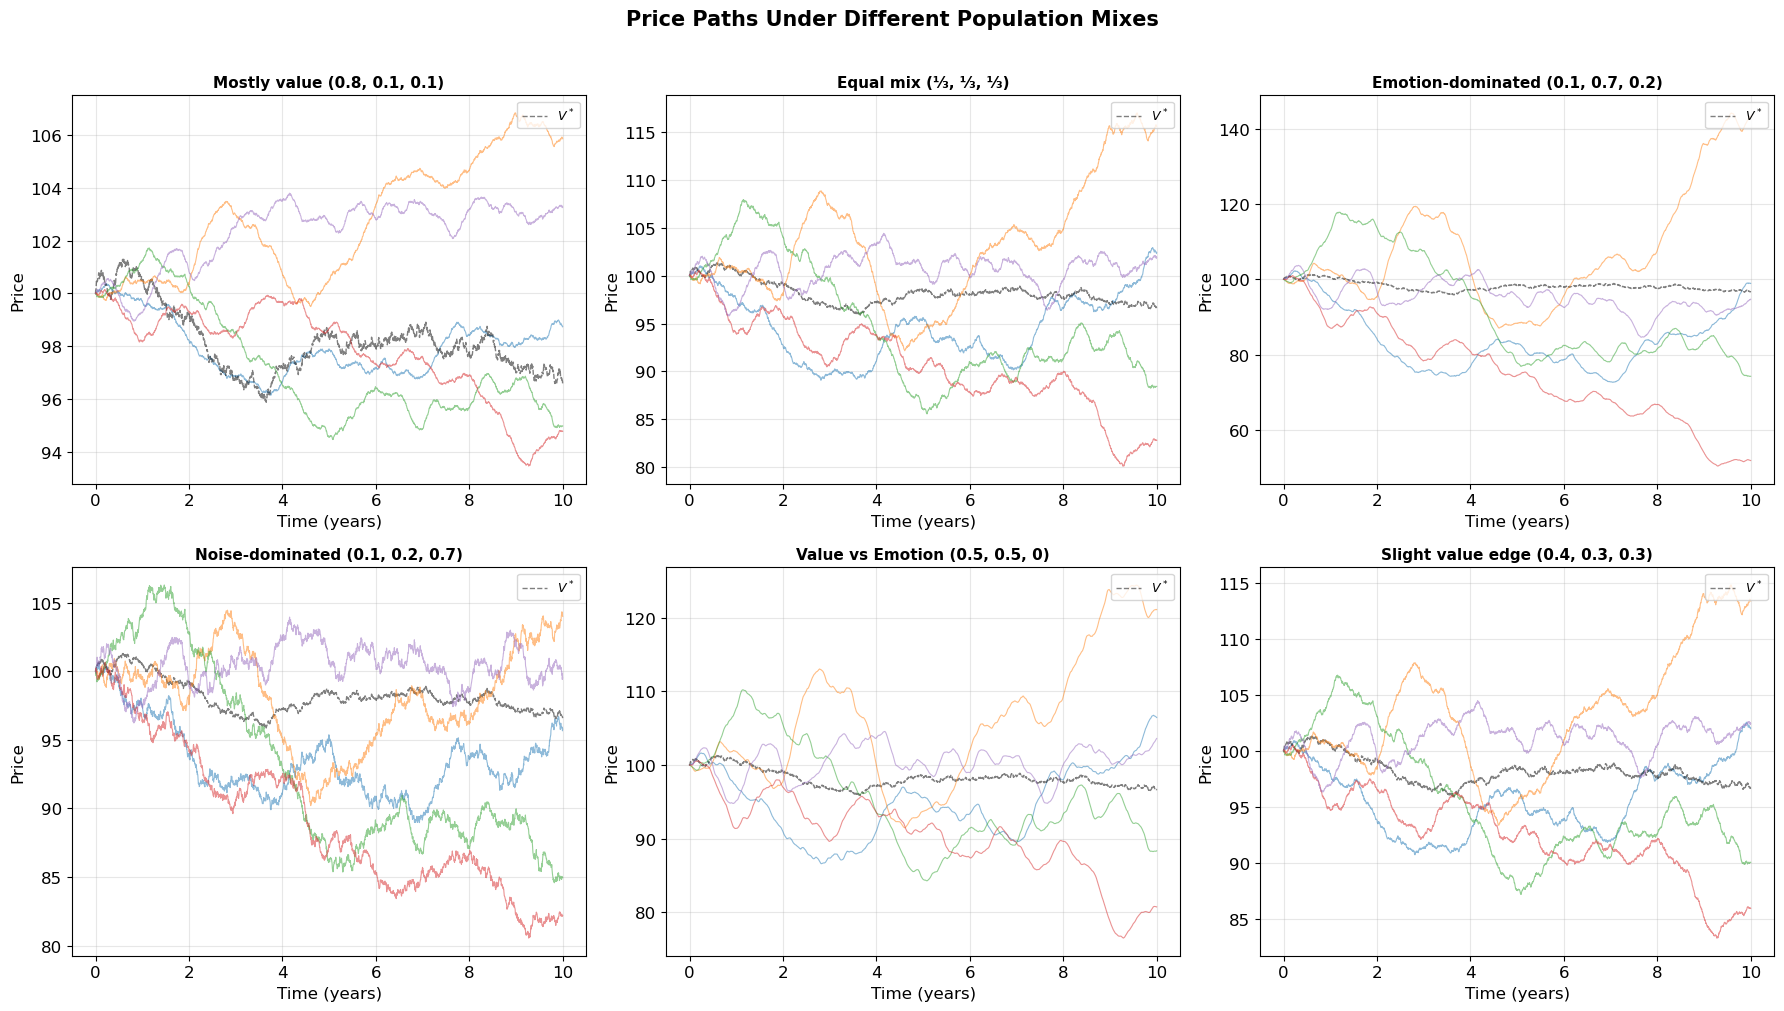

In [7]:
mixes = [
    ((0.8, 0.1, 0.1), 'Mostly value (0.8, 0.1, 0.1)'),
    ((0.33, 0.34, 0.33), 'Equal mix (⅓, ⅓, ⅓)'),
    ((0.1, 0.7, 0.2), 'Emotion-dominated (0.1, 0.7, 0.2)'),
    ((0.1, 0.2, 0.7), 'Noise-dominated (0.1, 0.2, 0.7)'),
    ((0.5, 0.5, 0.0), 'Value vs Emotion (0.5, 0.5, 0)'),
    ((0.4, 0.3, 0.3), 'Slight value edge (0.4, 0.3, 0.3)'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (pop, title) in zip(axes.flat, mixes):
    for i in range(5):
        result = simulate_market(pop, params, seed=i)
        ax.plot(result['time'], result['price'], alpha=0.5, linewidth=0.8)
        if i == 0:
            ax.plot(result['time'], result['fair_value'], 'k--', 
                    alpha=0.5, linewidth=1, label='$V^*$')
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Price')
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle('Price Paths Under Different Population Mixes', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Simplex Analysis: Convergence Metrics

Now the core analysis: sweep the entire 2-simplex and compute summary statistics at each point.

For each population mix $(p_1, p_2, p_3)$, run Monte Carlo and measure:
1. **Mean absolute mispricing**: $\mathbb{E}[|\log(P/V^*)|]$ — how far price deviates from fair value
2. **Excess volatility ratio**: $\sigma_P / \sigma_V$ — realized vol vs fundamental vol
3. **Convergence probability**: fraction of paths where $|\log(P_T / V^*_T)| < \epsilon$

In [8]:
def compute_metrics(
    p: Tuple[float, float, float],
    params: ModelParams = ModelParams(),
    n_mc: int = 50,
    convergence_threshold: float = 0.1,
) -> dict:
    """Compute summary statistics for a given population mix via Monte Carlo."""
    
    mispricings = []
    vol_ratios = []
    converged = 0
    
    for i in range(n_mc):
        result = simulate_market(p, params, seed=i * 1000 + hash(p) % 1000)
        
        # Mean absolute mispricing (second half of simulation to allow equilibration)
        half = len(result['mispricing']) // 2
        mean_mispricing = np.mean(np.abs(result['mispricing'][half:]))
        mispricings.append(mean_mispricing)
        
        # Excess volatility ratio
        price_vol = np.std(result['returns'][1:]) * np.sqrt(252)
        fair_returns = np.diff(np.log(result['fair_value']))
        fair_vol = np.std(fair_returns) * np.sqrt(252)
        if fair_vol > 1e-10:
            vol_ratios.append(price_vol / fair_vol)
        
        # Convergence check (final mispricing)
        if np.abs(result['mispricing'][-1]) < convergence_threshold:
            converged += 1
    
    return {
        'mean_mispricing': np.mean(mispricings),
        'std_mispricing': np.std(mispricings),
        'excess_vol': np.mean(vol_ratios) if vol_ratios else np.nan,
        'convergence_prob': converged / n_mc,
    }

In [9]:
# Sweep the simplex with a triangular grid
# Resolution: n_grid points along each edge
n_grid = 20  # increase for finer resolution (but slower)
n_mc = 30    # Monte Carlo paths per grid point

grid_points = []
for i in range(n_grid + 1):
    for j in range(n_grid + 1 - i):
        k = n_grid - i - j
        p1 = i / n_grid
        p2 = j / n_grid
        p3 = k / n_grid
        grid_points.append((p1, p2, p3))

print(f"Sweeping {len(grid_points)} points on the simplex with {n_mc} MC paths each...")
print(f"Total simulations: {len(grid_points) * n_mc}")

Sweeping 231 points on the simplex with 30 MC paths each...
Total simulations: 6930


In [10]:
# Run the sweep (this is the expensive part — ~2-5 min depending on resolution)
from time import time as timer

results_grid = []
t_start = timer()

for idx, p in enumerate(grid_points):
    metrics = compute_metrics(p, params, n_mc=n_mc)
    results_grid.append({
        'p1': p[0], 'p2': p[1], 'p3': p[2],
        **metrics
    })
    
    # Progress update
    if (idx + 1) % 50 == 0:
        elapsed = timer() - t_start
        rate = (idx + 1) / elapsed
        remaining = (len(grid_points) - idx - 1) / rate
        print(f"  {idx+1}/{len(grid_points)} ({elapsed:.0f}s elapsed, ~{remaining:.0f}s remaining)")

elapsed = timer() - t_start
print(f"\nDone! {len(grid_points)} points in {elapsed:.1f}s ({elapsed/len(grid_points):.3f}s per point)")

  50/231 (23s elapsed, ~84s remaining)
  100/231 (46s elapsed, ~60s remaining)
  150/231 (69s elapsed, ~37s remaining)
  200/231 (91s elapsed, ~14s remaining)

Done! 231 points in 105.1s (0.455s per point)


## 7. Phase Diagrams on the Simplex

Plot the results as ternary heatmaps (projected onto 2D triangles).

In [12]:
def ternary_coords(p1, p2, p3):
    """Convert simplex coordinates to 2D Cartesian for plotting.
    
    Uses standard ternary projection:
      x = p2 + p3/2
      y = p3 * sqrt(3)/2
    
    Vertices: p1=1 at (0,0), p2=1 at (1,0), p3=1 at (0.5, sqrt(3)/2)
    """
    x = p2 + p3 * 0.5
    y = p3 * np.sqrt(3) / 2
    return x, y


def plot_ternary_heatmap(results, metric_key, title, cmap='RdYlGn_r', vmin=None, vmax=None):
    """Plot a metric on the ternary simplex."""
    
    p1_arr = np.array([r['p1'] for r in results])
    p2_arr = np.array([r['p2'] for r in results])
    p3_arr = np.array([r['p3'] for r in results])
    values = np.array([r[metric_key] for r in results])
    
    x, y = ternary_coords(p1_arr, p2_arr, p3_arr)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Triangulation for smooth interpolation
    triang = mtri.Triangulation(x, y)
    
    # Plot filled contours
    levels = 20
    if vmin is not None and vmax is not None:
        levels = np.linspace(vmin, vmax, 20)
    
    tcf = ax.tricontourf(triang, values, levels=levels, cmap=cmap, extend='both')
    ax.tricontour(triang, values, levels=levels, colors='k', linewidths=0.3, alpha=0.3)
    
    # Draw simplex edges
    triangle = plt.Polygon(
        [ternary_coords(1,0,0), ternary_coords(0,1,0), ternary_coords(0,0,1)],
        fill=False, edgecolor='black', linewidth=2
    )
    ax.add_patch(triangle)
    
    # Labels at vertices
    offset = 0.05
    ax.text(*ternary_coords(1, 0, 0), '\nType I\n(Value)', 
            ha='center', va='top', fontsize=12, fontweight='bold')
    ax.text(*ternary_coords(0, 1, 0), '\nType II\n(Emotion)', 
            ha='center', va='top', fontsize=12, fontweight='bold')
    tx, ty = ternary_coords(0, 0, 1)
    ax.text(tx, ty + offset, 'Type III\n(Noise)', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.colorbar(tcf, ax=ax, label=title, shrink=0.8)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_aspect('equal')
    ax.axis('off')
    
    plt.tight_layout()
    return fig

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/var/folders/0_/rjjvttq17y7gzh5lz00z4vt80000gn/T/ipykernel_27335/1408822438.py:4: SyntaxWarning: invalid escape sequence '\m'
  'Mean Absolute Mispricing $\mathbb{E}[|\\log(P/V^*)|]$',


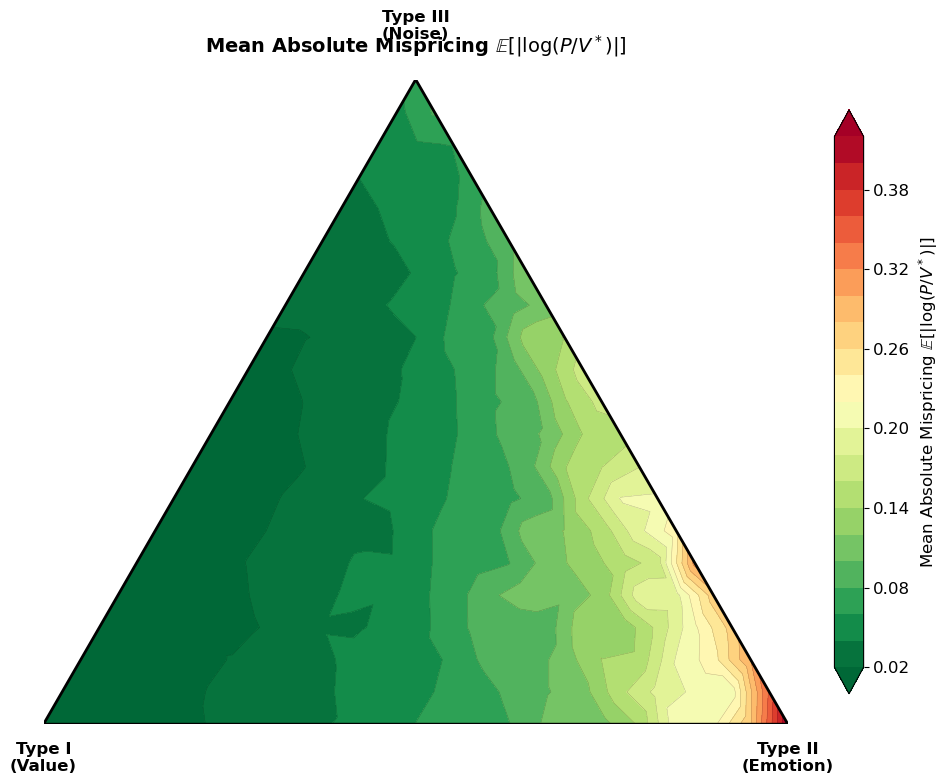

In [13]:
# Mean Absolute Mispricing
fig1 = plot_ternary_heatmap(
    results_grid, 'mean_mispricing',
    'Mean Absolute Mispricing $\mathbb{E}[|\\log(P/V^*)|]$',
    cmap='RdYlGn_r'
)
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/0_/rjjvttq17y7gzh5lz00z4vt80000gn/T/ipykernel_27335/2099044433.py:4: SyntaxWarning: invalid escape sequence '\s'
  'Excess Volatility Ratio $\sigma_P / \sigma_V$',


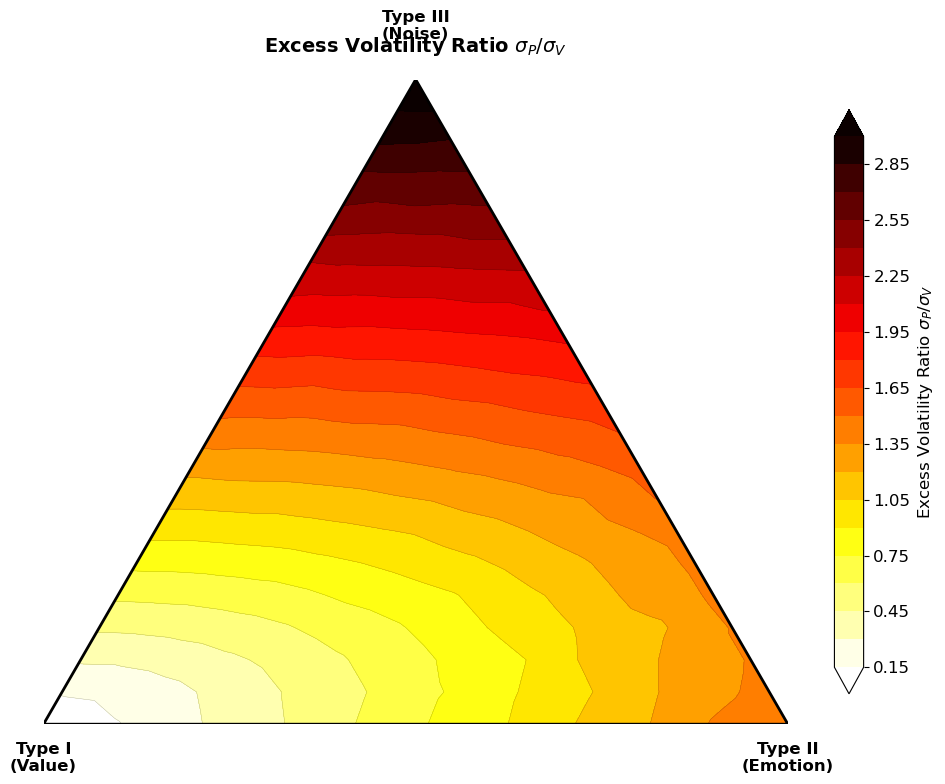

In [14]:
# Excess Volatility Ratio
fig2 = plot_ternary_heatmap(
    results_grid, 'excess_vol',
    'Excess Volatility Ratio $\sigma_P / \sigma_V$',
    cmap='hot_r'
)
plt.show()

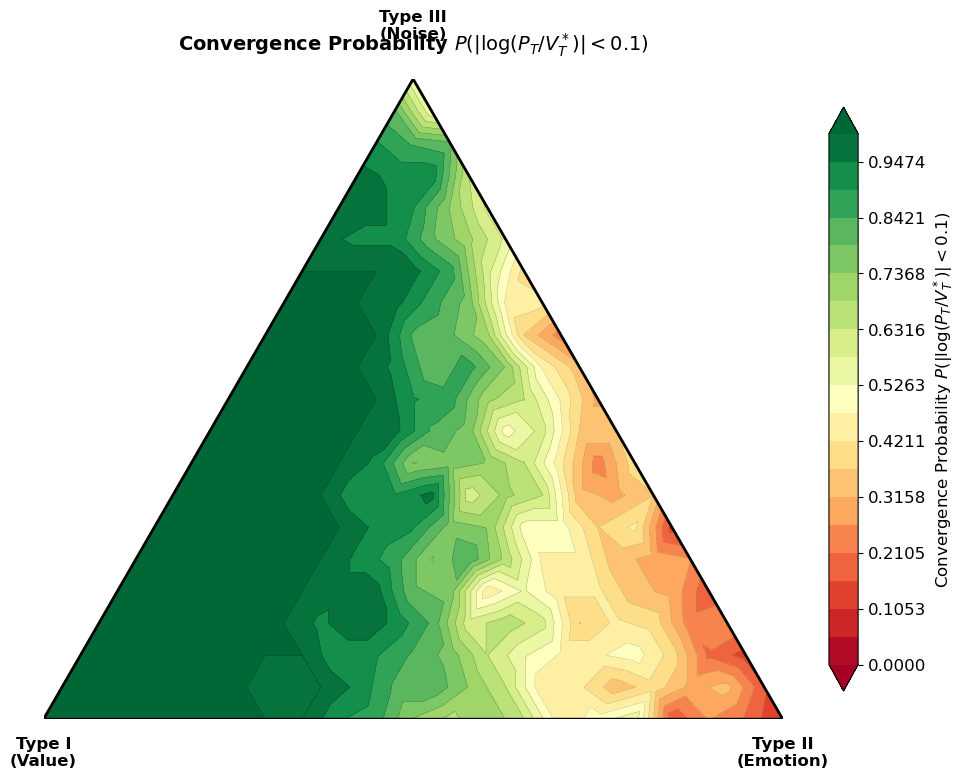

In [15]:
# Convergence Probability
fig3 = plot_ternary_heatmap(
    results_grid, 'convergence_prob',
    'Convergence Probability $P(|\\log(P_T/V^*_T)| < 0.1)$',
    cmap='RdYlGn',
    vmin=0, vmax=1
)
plt.show()

## 8. Mispricing Distribution Analysis

Bouchaud et al. (2026) found that mispricing distributions are often **bimodal**. Let's check.

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/var/folders/0_/rjjvttq17y7gzh5lz00z4vt80000gn/T/ipykernel_27335/970585383.py:24: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'{title}\n$\mathbf{{p}}$ = {pop}', fontsize=11, fontweight='bold')


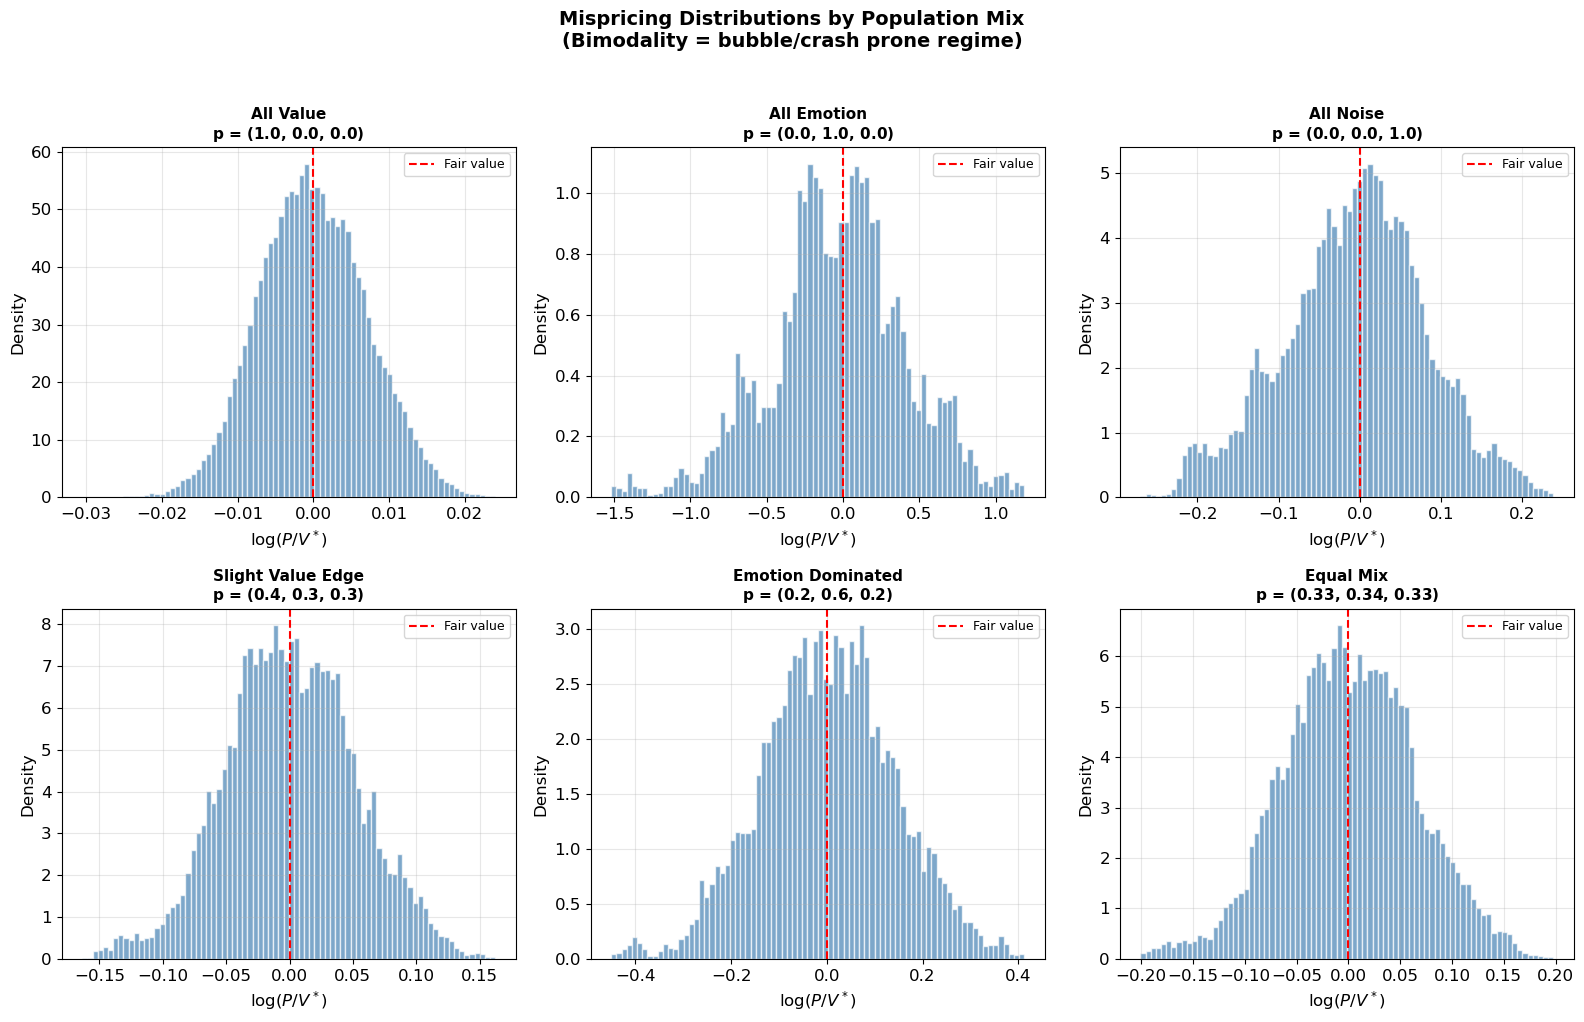

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

test_mixes = [
    ((1.0, 0.0, 0.0), 'All Value'),
    ((0.0, 1.0, 0.0), 'All Emotion'),
    ((0.0, 0.0, 1.0), 'All Noise'),
    ((0.4, 0.3, 0.3), 'Slight Value Edge'),
    ((0.2, 0.6, 0.2), 'Emotion Dominated'),
    ((0.33, 0.34, 0.33), 'Equal Mix'),
]

for ax, (pop, title) in zip(axes.flat, test_mixes):
    all_mispricings = []
    for i in range(100):
        result = simulate_market(pop, params, seed=i)
        # Collect second-half mispricings
        half = len(result['mispricing']) // 2
        all_mispricings.extend(result['mispricing'][half:])
    
    all_mispricings = np.array(all_mispricings)
    
    ax.hist(all_mispricings, bins=80, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Fair value')
    ax.set_title(f'{title}\n$\mathbf{{p}}$ = {pop}', fontsize=11, fontweight='bold')
    ax.set_xlabel('$\\log(P/V^*)$')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Mispricing Distributions by Population Mix\n(Bimodality = bubble/crash prone regime)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Demand Decomposition

Visualize how the three demand components interact for a single path.

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/var/folders/0_/rjjvttq17y7gzh5lz00z4vt80000gn/T/ipykernel_27335/4191453966.py:11: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('Demand Decomposition — $\mathbf{p}$ = (0.25, 0.50, 0.25)',


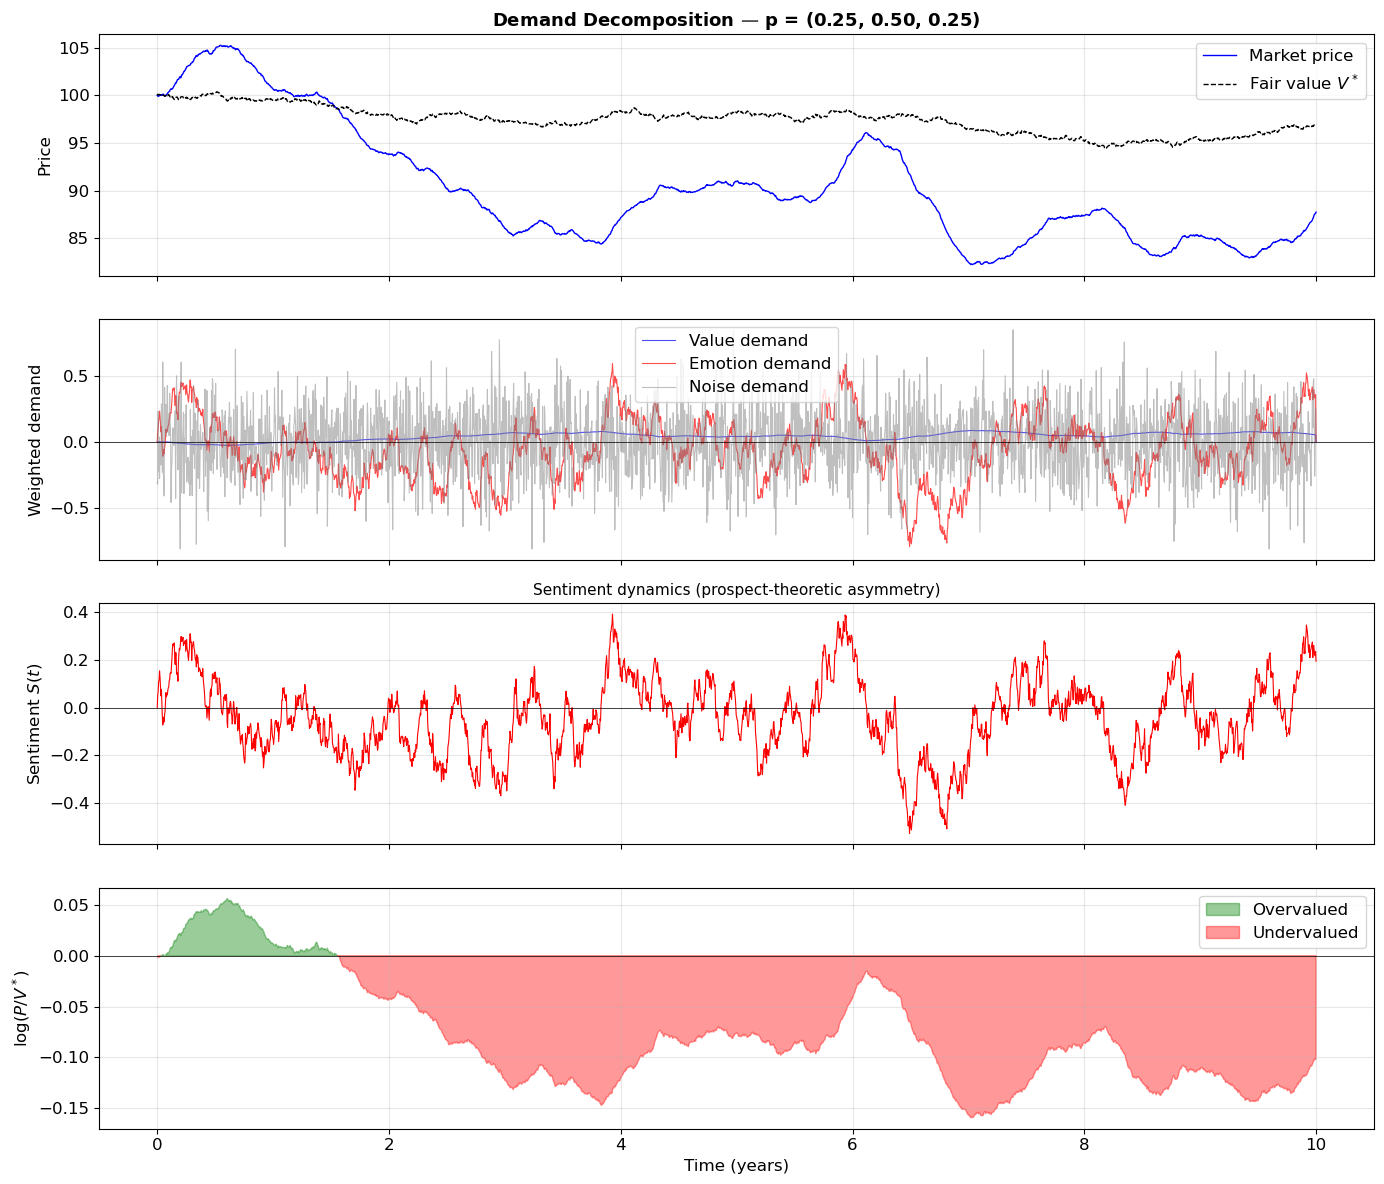

In [17]:
# Interesting mix: emotion-heavy market
result = simulate_market((0.25, 0.50, 0.25), params, seed=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Price vs Fair Value
axes[0].plot(result['time'], result['price'], 'b-', linewidth=1, label='Market price')
axes[0].plot(result['time'], result['fair_value'], 'k--', linewidth=1, label='Fair value $V^*$')
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].set_title('Demand Decomposition — $\mathbf{p}$ = (0.25, 0.50, 0.25)', 
                   fontsize=13, fontweight='bold')

# Individual demands
axes[1].plot(result['time'], 0.25 * result['demand_value'], 'b-', alpha=0.7, linewidth=0.8, label='Value demand')
axes[1].plot(result['time'], 0.50 * result['demand_emotion'], 'r-', alpha=0.7, linewidth=0.8, label='Emotion demand')
axes[1].plot(result['time'], 0.25 * result['demand_noise'], 'gray', alpha=0.5, linewidth=0.8, label='Noise demand')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_ylabel('Weighted demand')
axes[1].legend()

# Sentiment
axes[2].plot(result['time'], result['sentiment'], 'r-', linewidth=0.8)
axes[2].axhline(0, color='k', linewidth=0.5)
axes[2].set_ylabel('Sentiment $S(t)$')
axes[2].set_title('Sentiment dynamics (prospect-theoretic asymmetry)', fontsize=11)

# Mispricing
axes[3].fill_between(result['time'], result['mispricing'], 0,
                      where=result['mispricing'] >= 0, alpha=0.4, color='green', label='Overvalued')
axes[3].fill_between(result['time'], result['mispricing'], 0,
                      where=result['mispricing'] < 0, alpha=0.4, color='red', label='Undervalued')
axes[3].axhline(0, color='k', linewidth=0.5)
axes[3].set_ylabel('$\\log(P/V^*)$')
axes[3].set_xlabel('Time (years)')
axes[3].legend()

plt.tight_layout()
plt.show()